# Model Evaluation and Candidate Selection

This notebook evaluates candidate fraud detection models on the holdout test set and cross-validation results. The objective is to compare model performance using fraud-relevant metrics such as precision, recall, F1-score, ROC-AUC, and PR-AUC, then recommend the strongest candidate model for threshold tuning and decision-system integration.


## Evaluation Objective

- Compare Logistic Regression and Random Forest on the untouched holdout test set.
- Evaluate models using fraud-specific metrics instead of relying on accuracy.
- Review cross-validation performance alongside holdout test performance.
- Analyze probability distributions, fraud risk ranking, and threshold sensitivity.
- Recommend the strongest production candidate model for business threshold tuning.
- Prepare evaluation outputs for downstream decision-system development.


## Load Evaluation Artifacts

This notebook expects notebook `13_model_training.ipynb` to have already saved the following evaluation artifacts:

- trained baseline model artifacts
- holdout test predictions and probabilities
- holdout metrics from training
- train/test split metadata

If any required file is missing, the notebook raises a clear error that tells you which file to regenerate from notebook `13_model_training.ipynb`.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    from IPython.display import display
except ImportError:
    display = print

sys.path.append(str(Path("..").resolve()))

from src.config import PROJECT_ROOT

NOTEBOOK_NAME = "14_model_evaluation"
TRAINING_NOTEBOOK_NAME = "13_model_training"

NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / NOTEBOOK_NAME
NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / NOTEBOOK_NAME
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_COMPARISON_FILE = REPORTS_TABLES_DIR / "model_comparison.csv"
THRESHOLD_SWEEP_FILE = REPORTS_TABLES_DIR / "threshold_debug_sweep.csv"
BEST_CANDIDATE_FILE = PROJECT_ROOT / "artifacts" / "best_candidate_model_name.json"

TRAINING_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / TRAINING_NOTEBOOK_NAME
TRAINING_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / TRAINING_NOTEBOOK_NAME

NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
BEST_CANDIDATE_FILE.parent.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
plt.style.use("default")

print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook figures dir: {NOTEBOOK_FIGURES_DIR}")
print(f"Notebook tables dir : {NOTEBOOK_TABLES_DIR}")


Project root: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection
Notebook figures dir: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation
Notebook tables dir : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/14_model_evaluation


In [2]:
EXPECTED_FILES = {
    "baseline_test_predictions": TRAINING_TABLES_DIR / "baseline_test_predictions.csv",
    "logreg_holdout_metrics": TRAINING_TABLES_DIR / "logistic_regression_holdout_metrics.csv",
    "rf_holdout_metrics": TRAINING_TABLES_DIR / "random_forest_holdout_metrics.csv",
    "cv_summary": TRAINING_TABLES_DIR / "cv_summary.csv",
    "cv_fold_metrics": TRAINING_TABLES_DIR / "cv_fold_metrics.csv",
    "training_artifact_manifest": TRAINING_TABLES_DIR / "training_artifact_manifest.csv",
    "train_test_split_ids": TRAINING_ARTIFACTS_DIR / "train_test_split_ids.json",
    "baseline_logistic_regression_model": TRAINING_ARTIFACTS_DIR / "baseline_logistic_regression.joblib",
    "baseline_random_forest_model": TRAINING_ARTIFACTS_DIR / "baseline_random_forest.joblib",
}


def require_file(path: Path, artifact_name: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required artifact: {artifact_name}\n"
            f"Expected path: {path}\n"
            "Regenerate it by re-running notebook '13_model_training.ipynb', especially the artifact-saving section."
        )
    return path


for artifact_name, artifact_path in EXPECTED_FILES.items():
    require_file(artifact_path, artifact_name)

print("All required notebook 13 artifacts were found.")


All required notebook 13 artifacts were found.


In [3]:
holdout_predictions = pd.read_csv(EXPECTED_FILES["baseline_test_predictions"])
logreg_training_metrics = pd.read_csv(EXPECTED_FILES["logreg_holdout_metrics"])
rf_training_metrics = pd.read_csv(EXPECTED_FILES["rf_holdout_metrics"])
cv_summary = pd.read_csv(EXPECTED_FILES["cv_summary"])
cv_fold_metrics = pd.read_csv(EXPECTED_FILES["cv_fold_metrics"])
artifact_manifest = pd.read_csv(EXPECTED_FILES["training_artifact_manifest"])

with EXPECTED_FILES["train_test_split_ids"].open("r", encoding="utf-8") as file:
    split_ids = json.load(file)

logreg_artifact = joblib.load(EXPECTED_FILES["baseline_logistic_regression_model"])
rf_artifact = joblib.load(EXPECTED_FILES["baseline_random_forest_model"])

required_prediction_columns = [
    "y_true",
    "logistic_regression_probability",
    "random_forest_probability",
    "logistic_regression_prediction_0_5",
    "random_forest_prediction_0_5",
]
missing_prediction_columns = sorted(set(required_prediction_columns) - set(holdout_predictions.columns))
if missing_prediction_columns:
    raise ValueError(
        "The holdout prediction file is missing required columns: "
        f"{missing_prediction_columns}. Re-run notebook '13_model_training.ipynb' so these outputs are regenerated."
    )

artifact_summary = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "artifact_type": type(logreg_artifact).__name__,
            "selected_feature_count": len(logreg_artifact.get("selected_features", [])),
            "selected_features_preview": ", ".join(logreg_artifact.get("selected_features", [])[:5]),
        },
        {
            "model": "Random Forest",
            "artifact_type": type(rf_artifact).__name__,
            "selected_feature_count": len(rf_artifact.get("selected_features", [])),
            "selected_features_preview": ", ".join(rf_artifact.get("selected_features", [])[:5]),
        },
    ]
)

input_snapshot = pd.DataFrame(
    [
        {"item": "Holdout rows", "value": int(len(holdout_predictions))},
        {"item": "Holdout fraud cases", "value": int(holdout_predictions["y_true"].sum())},
        {"item": "Holdout fraud rate", "value": float(holdout_predictions["y_true"].mean())},
        {"item": "Train transaction IDs saved", "value": len(split_ids["train_transaction_ids"])},
        {"item": "Test transaction IDs saved", "value": len(split_ids["test_transaction_ids"])},
    ]
)

display(input_snapshot)
display(artifact_summary)
display(cv_summary)


,item,value
0,Holdout rows,56746.000000
1,Holdout fraud cases,95.000000
2,Holdout fraud rate,0.001674
3,Train transaction IDs saved,226980.000000
4,Test transaction IDs saved,56746.000000


,model,artifact_type,selected_feature_count,selected_features_preview
0,Logistic Regression,dict,13,"V14_V12_interaction, V14, V17_V16_interaction,..."
1,Random Forest,dict,13,"V14_V12_interaction, V14, V17_V16_interaction,..."


,model_name,metric_scope,precision,recall,f1,roc_auc,pr_auc
0,logistic_regression,cv_mean,0.058001,0.899474,0.108912,0.980965,0.719556
1,logistic_regression,cv_std,0.004037,0.047509,0.007022,0.006458,0.034909
2,random_forest,cv_mean,0.936752,0.777825,0.848648,0.939283,0.829859
3,random_forest,cv_std,0.023887,0.059542,0.039487,0.017390,0.041051


## Evaluation Utilities

The helpers below standardize fraud-model evaluation, diagnostics, and output saving.

- Precision matters because too many false alerts create customer friction and manual review cost.
- Recall matters because false negatives mean real fraud is missed.
- F1-score summarizes the precision and recall balance.
- ROC-AUC and PR-AUC measure ranking quality across thresholds.
- Confusion-matrix counts make the business trade-off concrete.


In [4]:
def save_dataframe_with_notice(df: pd.DataFrame, output_path: Path, index: bool = False):
    status = "Overwriting existing file" if output_path.exists() else "Saving new file"
    print(f"{status}: {output_path}")
    df.to_csv(output_path, index=index)


def save_json_with_notice(payload: dict, output_path: Path):
    status = "Overwriting existing file" if output_path.exists() else "Saving new file"
    print(f"{status}: {output_path}")
    output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def save_figure_with_notice(fig, output_path: Path, dpi: int = 150):
    status = "Overwriting existing file" if output_path.exists() else "Saving new file"
    print(f"{status}: {output_path}")
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")


def evaluate_model(model_name, y_true, y_pred, y_proba):
    """Evaluate a fraud model using thresholded and probability-based metrics."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results = {
        "model_name": model_name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }

    print(f"\n{'=' * 80}")
    print(f"{model_name} Holdout Classification Report — Default Threshold 0.50")
    print("=" * 80)
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("Confusion Matrix")
    display(
        pd.DataFrame(
            cm,
            index=["Actual Legit (0)", "Actual Fraud (1)"],
            columns=["Predicted Legit (0)", "Predicted Fraud (1)"],
        )
    )
    display(pd.DataFrame([results]))
    return results


def plot_confusion_matrix_figure(model_label, cm, output_path):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, cmap="Blues")

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col, row, f"{cm[row, col]:,}", ha="center", va="center", color="black", fontsize=11)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted Legit", "Predicted Fraud"])
    ax.set_yticklabels(["Actual Legit", "Actual Fraud"])
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.set_title(f"{model_label} Confusion Matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    save_figure_with_notice(fig, output_path)
    plt.show()
    plt.close(fig)


def build_business_interpretation(metrics_row):
    if metrics_row["False Positives"] <= 10 and metrics_row["Precision"] >= 0.80:
        return "Low false-alert burden with strong precision. Good candidate for review and block decision tuning."
    if metrics_row["Recall"] >= 0.80 and metrics_row["Precision"] < 0.20:
        return "High fraud catch rate, but false alerts are too high for stable customer-facing decisions."
    return "Balanced baseline with meaningful fraud capture, but threshold tuning is still needed before deployment."


def summarize_threshold_predictions(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "model_name": model_name,
        "total_rows": int(len(y_true)),
        "actual_fraud_cases": int(np.sum(y_true)),
        "predicted_fraud_at_0_5": int(np.sum(y_pred)),
        "predicted_normal_at_0_5": int(len(y_pred) - np.sum(y_pred)),
        "true_positives_at_0_5": int(tp),
        "false_positives_at_0_5": int(fp),
        "false_negatives_at_0_5": int(fn),
        "true_negatives_at_0_5": int(tn),
    }


def summarize_probability_distribution(probabilities, y_true, model_name):
    quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

    def build_row(label, series):
        desc = series.describe(percentiles=quantiles)
        return {
            "model_name": model_name,
            "group": label,
            "count": int(desc["count"]),
            "mean": float(desc["mean"]),
            "std": float(desc["std"] if pd.notna(desc["std"]) else 0.0),
            "min": float(desc["min"]),
            "1%": float(desc["1%"]),
            "5%": float(desc["5%"]),
            "10%": float(desc["10%"]),
            "25%": float(desc["25%"]),
            "50%": float(desc["50%"]),
            "75%": float(desc["75%"]),
            "90%": float(desc["90%"]),
            "95%": float(desc["95%"]),
            "99%": float(desc["99%"]),
            "max": float(desc["max"]),
        }

    series_all = pd.Series(probabilities)
    series_normal = pd.Series(probabilities)[pd.Series(y_true) == 0]
    series_fraud = pd.Series(probabilities)[pd.Series(y_true) == 1]

    return pd.DataFrame(
        [
            build_row("overall", series_all),
            build_row("y_true=0_normal", series_normal),
            build_row("y_true=1_fraud", series_fraud),
        ]
    )


def inspect_top_risk_cases(df, model_name, probability_column, top_n=30):
    top_cases = (
        df.loc[:, ["transaction_id", "y_true", probability_column]]
        .sort_values(probability_column, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    coverage_rows = []
    for cutoff in [10, 25, 50, 100, 250, 500]:
        fraud_hits = int(
            df.sort_values(probability_column, ascending=False)
            .head(cutoff)["y_true"]
            .sum()
        )
        coverage_rows.append(
            {
                "model_name": model_name,
                "top_k": cutoff,
                "actual_fraud_in_top_k": fraud_hits,
            }
        )

    coverage_df = pd.DataFrame(coverage_rows)
    return top_cases, coverage_df


def run_threshold_sweep(model_name, y_true, probabilities, thresholds):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rows.append(
            {
                "model_name": model_name,
                "threshold": float(threshold),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "predicted_fraud_count": int(np.sum(y_pred)),
                "true_positives": int(tp),
                "false_positives": int(fp),
                "false_negatives": int(fn),
                "true_negatives": int(tn),
            }
        )
    return pd.DataFrame(rows)


def extract_best_thresholds(threshold_sweep_df, model_name):
    model_df = threshold_sweep_df.loc[threshold_sweep_df["model_name"] == model_name].copy()
    best_f1_row = model_df.sort_values(["f1", "precision", "recall"], ascending=[False, False, False]).iloc[0]

    summary_rows = [
        {
            "model_name": model_name,
            "selection_rule": "best_f1",
            "threshold": float(best_f1_row["threshold"]),
            "precision": float(best_f1_row["precision"]),
            "recall": float(best_f1_row["recall"]),
            "f1": float(best_f1_row["f1"]),
            "predicted_fraud_count": int(best_f1_row["predicted_fraud_count"]),
        }
    ]

    for recall_floor in [0.70, 0.80]:
        eligible = model_df.loc[model_df["recall"] >= recall_floor].copy()
        if eligible.empty:
            summary_rows.append(
                {
                    "model_name": model_name,
                    "selection_rule": f"highest_precision_with_recall_at_least_{recall_floor:.2f}",
                    "threshold": np.nan,
                    "precision": np.nan,
                    "recall": np.nan,
                    "f1": np.nan,
                    "predicted_fraud_count": np.nan,
                }
            )
            continue

        best_row = eligible.sort_values(["precision", "f1", "threshold"], ascending=[False, False, True]).iloc[0]
        summary_rows.append(
            {
                "model_name": model_name,
                "selection_rule": f"highest_precision_with_recall_at_least_{recall_floor:.2f}",
                "threshold": float(best_row["threshold"]),
                "precision": float(best_row["precision"]),
                "recall": float(best_row["recall"]),
                "f1": float(best_row["f1"]),
                "predicted_fraud_count": int(best_row["predicted_fraud_count"]),
            }
        )

    return pd.DataFrame(summary_rows)


def plot_threshold_curve(threshold_sweep_df, metric_name, output_path, title, y_label):
    fig, ax = plt.subplots(figsize=(8, 5))
    for model_name in threshold_sweep_df["model_name"].unique():
        model_df = threshold_sweep_df.loc[threshold_sweep_df["model_name"] == model_name]
        ax.plot(model_df["threshold"], model_df[metric_name], marker="o", linewidth=2, label=model_name)

    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_figure_with_notice(fig, output_path)
    plt.show()
    plt.close(fig)


## Logistic Regression Holdout Evaluation

This section evaluates Logistic Regression on the holdout test set at the default threshold of `0.50`. High recall can help catch more fraud, but low precision can create many false alerts and unnecessary manual reviews.



Logistic Regression Holdout Classification Report — Default Threshold 0.50
              precision    recall  f1-score   support

           0     0.9983    0.9747    0.9864     56651
           1     0.0021    0.0316    0.0039        95

    accuracy                         0.9731     56746
   macro avg     0.5002    0.5031    0.4951     56746
weighted avg     0.9967    0.9731    0.9847     56746

Confusion Matrix


,Predicted Legit (0),Predicted Fraud (1)
Actual Legit (0),55215,1436
Actual Fraud (1),92,3


,model_name,precision,recall,f1_score,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,Logistic Regression,0.002085,0.031579,0.003911,0.960592,0.641876,55215,1436,92,3


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/logistic_regression_confusion_matrix.png


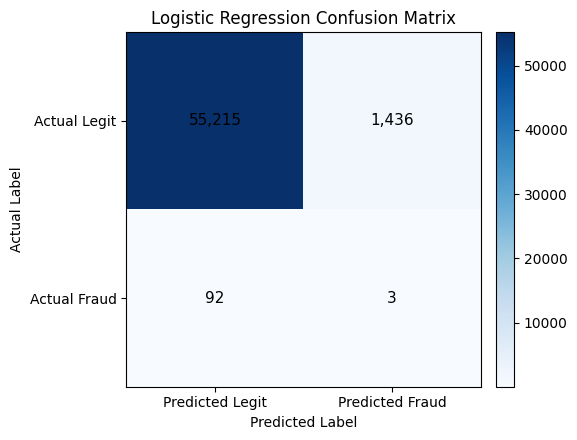

In [5]:
y_true = holdout_predictions["y_true"]

logreg_results = evaluate_model(
    model_name="Logistic Regression",
    y_true=y_true,
    y_pred=holdout_predictions["logistic_regression_prediction_0_5"],
    y_proba=holdout_predictions["logistic_regression_probability"],
)

logreg_cm = confusion_matrix(y_true, holdout_predictions["logistic_regression_prediction_0_5"])
logreg_cm_path = NOTEBOOK_FIGURES_DIR / "logistic_regression_confusion_matrix.png"
plot_confusion_matrix_figure("Logistic Regression", logreg_cm, logreg_cm_path)


## Random Forest Holdout Evaluation

This section evaluates Random Forest on the holdout test set at the default threshold of `0.50`. Random Forest can reduce false positives and improve precision, but recall must still be reviewed because missed fraud is costly.



Random Forest Holdout Classification Report — Default Threshold 0.50
              precision    recall  f1-score   support

           0     0.9983    0.9987    0.9985     56651
           1     0.0137    0.0105    0.0119        95

    accuracy                         0.9971     56746
   macro avg     0.5060    0.5046    0.5052     56746
weighted avg     0.9967    0.9971    0.9969     56746

Confusion Matrix


,Predicted Legit (0),Predicted Fraud (1)
Actual Legit (0),56579,72
Actual Fraud (1),94,1


,model_name,precision,recall,f1_score,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,Random Forest,0.013699,0.010526,0.011905,0.924765,0.802161,56579,72,94,1


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/random_forest_confusion_matrix.png


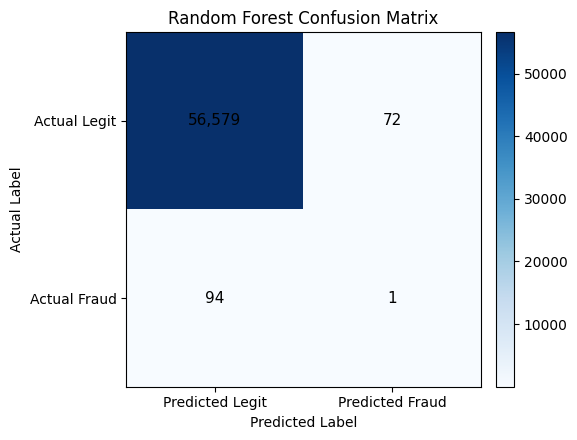

In [6]:
rf_results = evaluate_model(
    model_name="Random Forest",
    y_true=y_true,
    y_pred=holdout_predictions["random_forest_prediction_0_5"],
    y_proba=holdout_predictions["random_forest_probability"],
)

rf_cm = confusion_matrix(y_true, holdout_predictions["random_forest_prediction_0_5"])
rf_cm_path = NOTEBOOK_FIGURES_DIR / "random_forest_confusion_matrix.png"
plot_confusion_matrix_figure("Random Forest", rf_cm, rf_cm_path)


## Candidate Model Comparison

The table below compares the candidate models using fraud-specific metrics and raw confusion-matrix counts.

Initial production candidate recommendation is deferred until probability distribution, fraud risk ranking, and threshold sensitivity are reviewed.


In [7]:
comparison_df = pd.DataFrame(
    [
        {
            "Model": logreg_results["model_name"],
            "Precision": logreg_results["precision"],
            "Recall": logreg_results["recall"],
            "F1-score": logreg_results["f1_score"],
            "ROC-AUC": logreg_results["roc_auc"],
            "PR-AUC": logreg_results["pr_auc"],
            "True Negatives": logreg_results["true_negatives"],
            "False Positives": logreg_results["false_positives"],
            "False Negatives": logreg_results["false_negatives"],
            "True Positives": logreg_results["true_positives"],
        },
        {
            "Model": rf_results["model_name"],
            "Precision": rf_results["precision"],
            "Recall": rf_results["recall"],
            "F1-score": rf_results["f1_score"],
            "ROC-AUC": rf_results["roc_auc"],
            "PR-AUC": rf_results["pr_auc"],
            "True Negatives": rf_results["true_negatives"],
            "False Positives": rf_results["false_positives"],
            "False Negatives": rf_results["false_negatives"],
            "True Positives": rf_results["true_positives"],
        },
    ]
)

comparison_df["Business Interpretation"] = comparison_df.apply(build_business_interpretation, axis=1)
save_dataframe_with_notice(comparison_df, MODEL_COMPARISON_FILE, index=False)
save_dataframe_with_notice(comparison_df, NOTEBOOK_TABLES_DIR / "model_comparison.csv", index=False)

display(comparison_df)


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/model_comparison.csv
Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/14_model_evaluation/model_comparison.csv


,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives,Business Interpretation
0,Logistic Regression,0.002085,0.031579,0.003911,0.960592,0.641876,55215,1436,92,3,Balanced baseline with meaningful fraud captur...
1,Random Forest,0.013699,0.010526,0.011905,0.924765,0.802161,56579,72,94,1,Balanced baseline with meaningful fraud captur...


## ROC-AUC Analysis and Precision-Recall Analysis

These plots compare the two candidate models from a ranking perspective. Precision-recall analysis is especially important for imbalanced fraud detection because PR-AUC focuses on how well the model identifies the rare fraud class.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/roc_curve_comparison.png


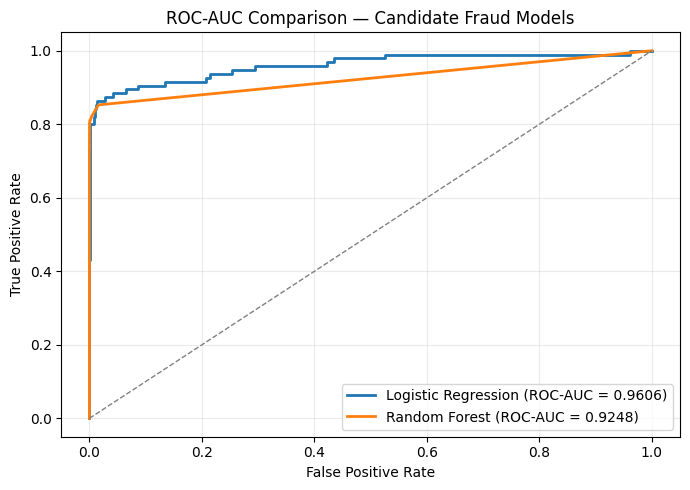

Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/precision_recall_curve_comparison.png


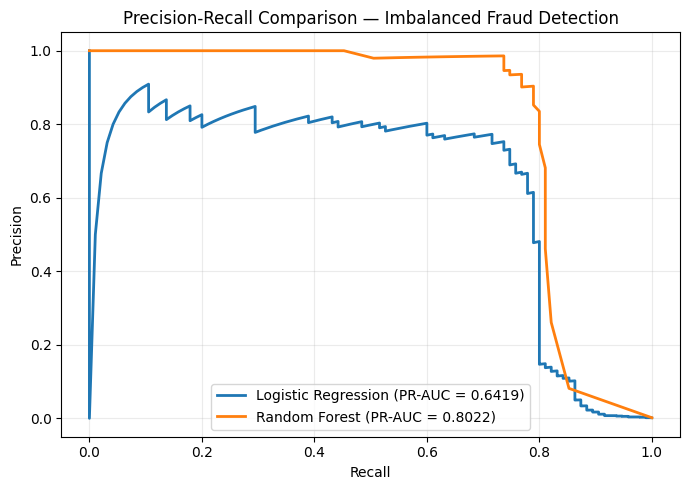

Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/metric_bar_comparison.png


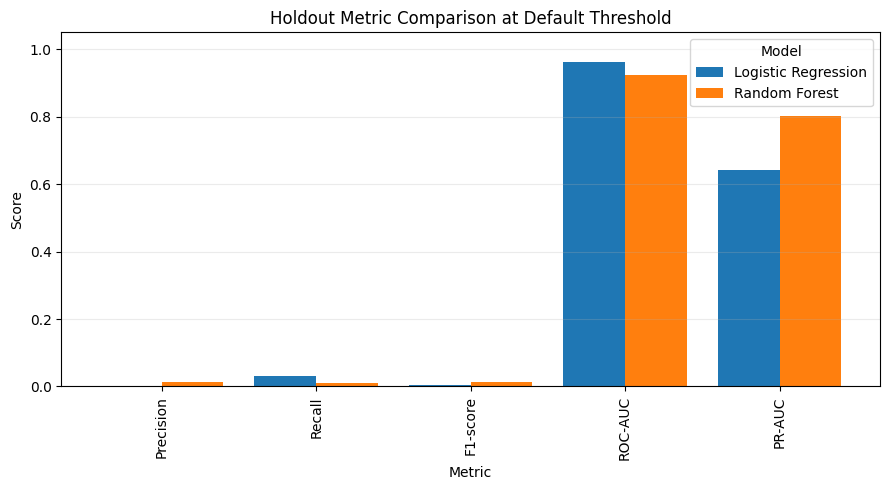

In [8]:
roc_output_path = NOTEBOOK_FIGURES_DIR / "roc_curve_comparison.png"
pr_output_path = NOTEBOOK_FIGURES_DIR / "precision_recall_curve_comparison.png"
bar_output_path = NOTEBOOK_FIGURES_DIR / "metric_bar_comparison.png"

logreg_fpr, logreg_tpr, _ = roc_curve(y_true, holdout_predictions["logistic_regression_probability"])
rf_fpr, rf_tpr, _ = roc_curve(y_true, holdout_predictions["random_forest_probability"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(logreg_fpr, logreg_tpr, label=f"Logistic Regression (ROC-AUC = {logreg_results['roc_auc']:.4f})", linewidth=2)
ax.plot(rf_fpr, rf_tpr, label=f"Random Forest (ROC-AUC = {rf_results['roc_auc']:.4f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("ROC-AUC Comparison — Candidate Fraud Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, roc_output_path)
plt.show()
plt.close(fig)

logreg_precision_curve, logreg_recall_curve, _ = precision_recall_curve(
    y_true,
    holdout_predictions["logistic_regression_probability"],
)
rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(
    y_true,
    holdout_predictions["random_forest_probability"],
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(logreg_recall_curve, logreg_precision_curve, label=f"Logistic Regression (PR-AUC = {logreg_results['pr_auc']:.4f})", linewidth=2)
ax.plot(rf_recall_curve, rf_precision_curve, label=f"Random Forest (PR-AUC = {rf_results['pr_auc']:.4f})", linewidth=2)
ax.set_title("Precision-Recall Comparison — Imbalanced Fraud Detection")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, pr_output_path)
plt.show()
plt.close(fig)

metrics_for_bar = comparison_df[["Model", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]].set_index("Model")
fig, ax = plt.subplots(figsize=(9, 5))
metrics_for_bar.T.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Holdout Metric Comparison at Default Threshold")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, bar_output_path)
plt.show()
plt.close(fig)


## Threshold Sensitivity Analysis

Cross-validation metrics may look strong while holdout classification performance at the default threshold of `0.50` looks weaker. This can happen in highly imbalanced fraud data because the default threshold is only a starting point, not the final business threshold.

ROC-AUC and PR-AUC evaluate ranking quality across many thresholds, while a classification report depends on one fixed threshold. Before recommending a production candidate model, this section inspects score distributions, fraud risk ranking quality, and threshold behavior.


In [9]:
debug_required_columns = [
    "y_true",
    "logistic_regression_probability",
    "random_forest_probability",
    "logistic_regression_prediction_0_5",
    "random_forest_prediction_0_5",
]

missing_debug_columns = sorted(set(debug_required_columns) - set(holdout_predictions.columns))
if missing_debug_columns:
    raise ValueError(
        "Debugging cannot continue because holdout_predictions is missing required columns: "
        f"{missing_debug_columns}. Re-run notebook '13_model_training.ipynb' to regenerate the saved holdout outputs."
    )

threshold_0_5_summary = pd.DataFrame(
    [
        summarize_threshold_predictions(
            "Logistic Regression",
            holdout_predictions["y_true"],
            holdout_predictions["logistic_regression_prediction_0_5"],
        ),
        summarize_threshold_predictions(
            "Random Forest",
            holdout_predictions["y_true"],
            holdout_predictions["random_forest_prediction_0_5"],
        ),
    ]
)

display(threshold_0_5_summary)


,model_name,total_rows,actual_fraud_cases,predicted_fraud_at_0_5,predicted_normal_at_0_5,true_positives_at_0_5,false_positives_at_0_5,false_negatives_at_0_5,true_negatives_at_0_5
0,Logistic Regression,56746,95,1439,55307,3,1436,92,55215
1,Random Forest,56746,95,73,56673,1,72,94,56579


In [10]:
logreg_probability_summary = summarize_probability_distribution(
    holdout_predictions["logistic_regression_probability"],
    holdout_predictions["y_true"],
    "Logistic Regression",
)
rf_probability_summary = summarize_probability_distribution(
    holdout_predictions["random_forest_probability"],
    holdout_predictions["y_true"],
    "Random Forest",
)

probability_distribution_summary = pd.concat(
    [logreg_probability_summary, rf_probability_summary],
    ignore_index=True,
)

display(probability_distribution_summary)


,model_name,group,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
0,Logistic Regression,overall,56746,0.085646,0.133645,3.193082e-09,0.001775,0.007594,0.012012,0.020737,0.041584,0.086219,0.198593,0.321062,0.797808,1.00
1,Logistic Regression,y_true=0_normal,56651,0.084335,0.129299,3.193082e-09,0.001771,0.007589,0.012000,0.020714,0.041513,0.085830,0.196621,0.315688,0.752833,1.00
2,Logistic Regression,y_true=1_fraud,95,0.867057,0.297580,6.308649e-03,0.036714,0.081551,0.240212,0.997265,0.999935,0.999998,1.000000,1.000000,1.000000,1.00
3,Random Forest,overall,56746,0.001452,0.033148,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.00
4,Random Forest,y_true=0_normal,56651,0.000292,0.006155,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.93
5,Random Forest,y_true=1_fraud,95,0.692842,0.395664,0.000000e+00,0.000000,0.000000,0.000000,0.285000,0.930000,0.970000,0.990000,1.000000,1.000000,1.00


In [11]:
logreg_top_30, logreg_top_k_hits = inspect_top_risk_cases(
    holdout_predictions,
    model_name="Logistic Regression",
    probability_column="logistic_regression_probability",
    top_n=30,
)
rf_top_30, rf_top_k_hits = inspect_top_risk_cases(
    holdout_predictions,
    model_name="Random Forest",
    probability_column="random_forest_probability",
    top_n=30,
)

print("Top 30 highest-risk transactions for Logistic Regression")
display(logreg_top_30)
display(logreg_top_k_hits)

print("Top 30 highest-risk transactions for Random Forest")
display(rf_top_30)
display(rf_top_k_hits)


Top 30 highest-risk transactions for Logistic Regression


,transaction_id,y_true,logistic_regression_probability
0,273745,0,1.000000
1,153640,1,1.000000
2,153242,1,1.000000
3,43498,1,1.000000
4,150420,1,1.000000
5,150337,1,1.000000
6,42979,1,1.000000
7,15683,1,1.000000
8,15423,1,1.000000
9,42755,1,1.000000


,model_name,top_k,actual_fraud_in_top_k
0,Logistic Regression,10,9
1,Logistic Regression,25,20
2,Logistic Regression,50,41
3,Logistic Regression,100,71
4,Logistic Regression,250,76
5,Logistic Regression,500,76


Top 30 highest-risk transactions for Random Forest


,transaction_id,y_true,random_forest_probability
0,228865,1,1.00
1,222745,1,1.00
2,43498,1,1.00
3,42755,1,1.00
4,42588,1,1.00
5,150110,1,1.00
6,150084,1,1.00
7,15683,1,1.00
8,213905,1,1.00
9,95238,1,0.99


,model_name,top_k,actual_fraud_in_top_k
0,Random Forest,10,10
1,Random Forest,25,25
2,Random Forest,50,49
3,Random Forest,100,76
4,Random Forest,250,78
5,Random Forest,500,80


In [12]:
thresholds = [
    0.01, 0.02, 0.03, 0.04, 0.05,
    0.075, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50,
    0.60, 0.70, 0.80, 0.90,
]

logreg_threshold_sweep = run_threshold_sweep(
    model_name="Logistic Regression",
    y_true=holdout_predictions["y_true"],
    probabilities=holdout_predictions["logistic_regression_probability"],
    thresholds=thresholds,
)
rf_threshold_sweep = run_threshold_sweep(
    model_name="Random Forest",
    y_true=holdout_predictions["y_true"],
    probabilities=holdout_predictions["random_forest_probability"],
    thresholds=thresholds,
)

threshold_debug_sweep = pd.concat([logreg_threshold_sweep, rf_threshold_sweep], ignore_index=True)
save_dataframe_with_notice(threshold_debug_sweep, THRESHOLD_SWEEP_FILE, index=False)
save_dataframe_with_notice(threshold_debug_sweep, NOTEBOOK_TABLES_DIR / "threshold_debug_sweep.csv", index=False)

display(threshold_debug_sweep)

logreg_best_thresholds = extract_best_thresholds(threshold_debug_sweep, "Logistic Regression")
rf_best_thresholds = extract_best_thresholds(threshold_debug_sweep, "Random Forest")
best_threshold_summary = pd.concat([logreg_best_thresholds, rf_best_thresholds], ignore_index=True)
display(best_threshold_summary)

for model_name in ["Logistic Regression", "Random Forest"]:
    model_summary = best_threshold_summary.loc[best_threshold_summary["model_name"] == model_name]
    best_f1_row = model_summary.loc[model_summary["selection_rule"] == "best_f1"].iloc[0]
    print(
        f"Best threshold by F1 for {model_name}: "
        f"threshold={best_f1_row['threshold']:.3f}, precision={best_f1_row['precision']:.4f}, "
        f"recall={best_f1_row['recall']:.4f}, f1={best_f1_row['f1']:.4f}"
    )

    for recall_floor in [0.70, 0.80]:
        recall_rule = f"highest_precision_with_recall_at_least_{recall_floor:.2f}"
        recall_row = model_summary.loc[model_summary["selection_rule"] == recall_rule].iloc[0]
        if pd.isna(recall_row["threshold"]):
            print(f"No threshold for {model_name} achieved recall >= {recall_floor:.2f} in the tested sweep.")
        else:
            print(
                f"Highest precision with recall >= {recall_floor:.2f} for {model_name}: "
                f"threshold={recall_row['threshold']:.3f}, precision={recall_row['precision']:.4f}, "
                f"recall={recall_row['recall']:.4f}, f1={recall_row['f1']:.4f}"
            )


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/threshold_debug_sweep.csv
Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/14_model_evaluation/threshold_debug_sweep.csv


,model_name,threshold,precision,recall,f1,predicted_fraud_count,true_positives,false_positives,false_negatives,true_negatives
0,Logistic Regression,0.010,0.001791,0.989474,0.003575,52488,94,52394,1,4257
1,Logistic Regression,0.020,0.002170,0.989474,0.004330,43322,94,43228,1,13423
2,Logistic Regression,0.030,0.002684,0.989474,0.005353,35024,94,34930,1,21721
3,Logistic Regression,0.040,0.003188,0.978947,0.006355,29172,93,29079,2,27572
4,Logistic Regression,0.050,0.003764,0.968421,0.007499,24443,92,24351,3,32300
5,Logistic Regression,0.075,0.005490,0.947368,0.010918,16392,90,16302,5,40349
6,Logistic Regression,0.100,0.007300,0.926316,0.014487,12054,88,11966,7,44685
7,Logistic Regression,0.150,0.011041,0.915789,0.021818,7880,87,7793,8,48858
8,Logistic Regression,0.200,0.015305,0.905263,0.030102,5619,86,5533,9,51118
9,Logistic Regression,0.250,0.020137,0.894737,0.039388,4221,85,4136,10,52515


,model_name,selection_rule,threshold,precision,recall,f1,predicted_fraud_count
0,Logistic Regression,best_f1,0.900,0.264808,0.800000,0.397906,287
1,Logistic Regression,highest_precision_with_recall_at_least_0.70,0.900,0.264808,0.800000,0.397906,287
2,Logistic Regression,highest_precision_with_recall_at_least_0.80,0.900,0.264808,0.800000,0.397906,287
3,Random Forest,best_f1,0.150,0.892857,0.789474,0.837989,84
4,Random Forest,highest_precision_with_recall_at_least_0.70,0.600,0.985714,0.726316,0.836364,70
5,Random Forest,highest_precision_with_recall_at_least_0.80,0.075,0.835165,0.800000,0.817204,91


Best threshold by F1 for Logistic Regression: threshold=0.900, precision=0.2648, recall=0.8000, f1=0.3979
Highest precision with recall >= 0.70 for Logistic Regression: threshold=0.900, precision=0.2648, recall=0.8000, f1=0.3979
Highest precision with recall >= 0.80 for Logistic Regression: threshold=0.900, precision=0.2648, recall=0.8000, f1=0.3979
Best threshold by F1 for Random Forest: threshold=0.150, precision=0.8929, recall=0.7895, f1=0.8380
Highest precision with recall >= 0.70 for Random Forest: threshold=0.600, precision=0.9857, recall=0.7263, f1=0.8364
Highest precision with recall >= 0.80 for Random Forest: threshold=0.075, precision=0.8352, recall=0.8000, f1=0.8172


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/debug_precision_vs_threshold.png


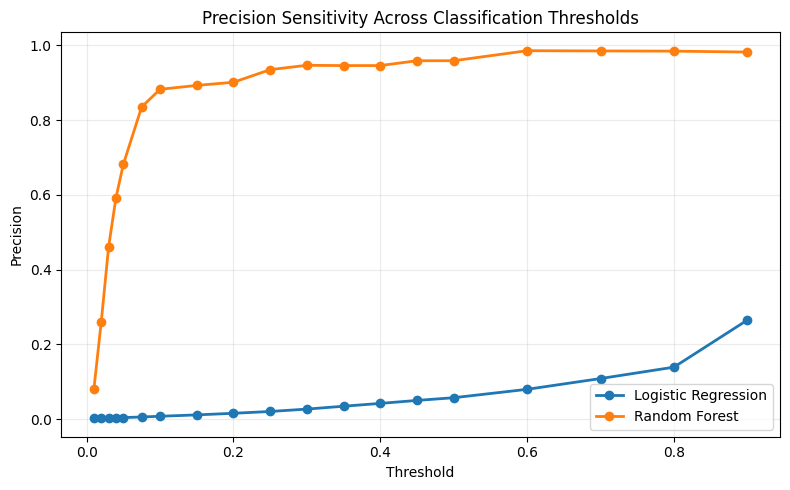

Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/debug_recall_vs_threshold.png


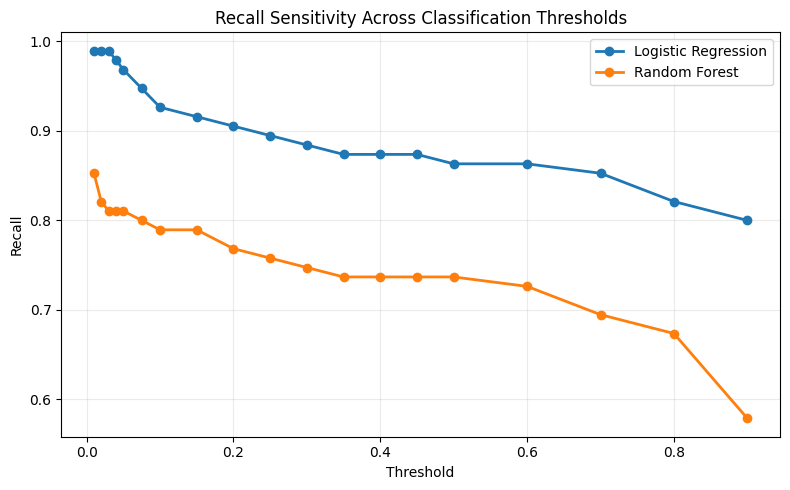

Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/debug_f1_vs_threshold.png


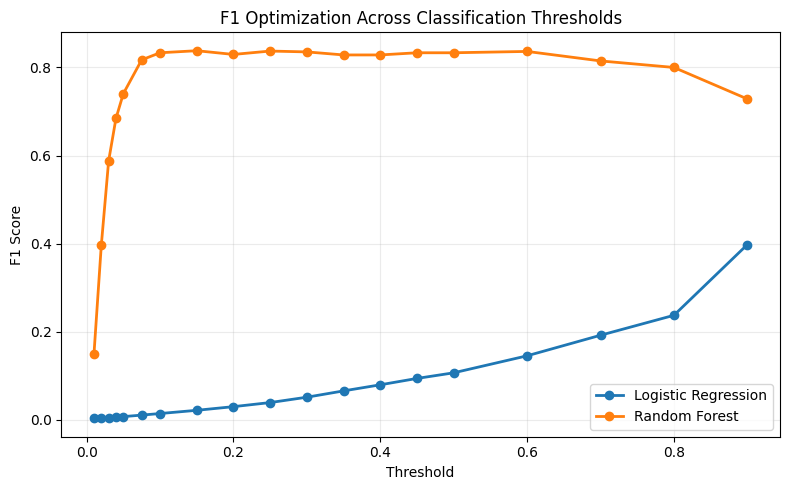

Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/debug_predicted_fraud_count_vs_threshold.png


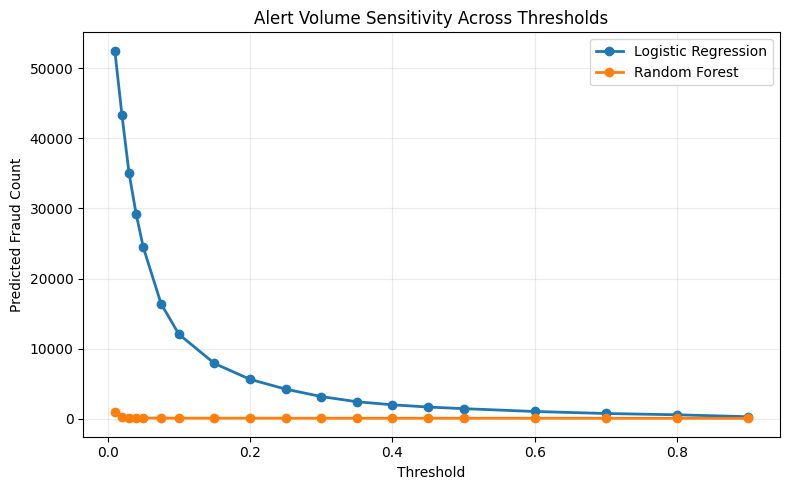

In [13]:
debug_precision_path = REPORTS_FIGURES_DIR / "debug_precision_vs_threshold.png"
debug_recall_path = REPORTS_FIGURES_DIR / "debug_recall_vs_threshold.png"
debug_f1_path = REPORTS_FIGURES_DIR / "debug_f1_vs_threshold.png"
debug_count_path = REPORTS_FIGURES_DIR / "debug_predicted_fraud_count_vs_threshold.png"

plot_threshold_curve(
    threshold_debug_sweep,
    metric_name="precision",
    output_path=debug_precision_path,
    title="Precision Sensitivity Across Classification Thresholds",
    y_label="Precision",
)
plot_threshold_curve(
    threshold_debug_sweep,
    metric_name="recall",
    output_path=debug_recall_path,
    title="Recall Sensitivity Across Classification Thresholds",
    y_label="Recall",
)
plot_threshold_curve(
    threshold_debug_sweep,
    metric_name="f1",
    output_path=debug_f1_path,
    title="F1 Optimization Across Classification Thresholds",
    y_label="F1 Score",
)
plot_threshold_curve(
    threshold_debug_sweep,
    metric_name="predicted_fraud_count",
    output_path=debug_count_path,
    title="Alert Volume Sensitivity Across Thresholds",
    y_label="Predicted Fraud Count",
)


## ROC-AUC and PR-AUC Holdout Summary

If ROC-AUC or PR-AUC remain strong while default-threshold recall is poor, the main issue is likely threshold selection rather than ranking quality.

If ROC-AUC and PR-AUC are also weak, the problem may be poor generalization, calibration drift, or a mismatch between the training pipeline and holdout behavior.


In [14]:
holdout_probability_metrics = pd.DataFrame(
    [
        {
            "model_name": "Logistic Regression",
            "roc_auc": roc_auc_score(y_true, holdout_predictions["logistic_regression_probability"]),
            "pr_auc": average_precision_score(y_true, holdout_predictions["logistic_regression_probability"]),
        },
        {
            "model_name": "Random Forest",
            "roc_auc": roc_auc_score(y_true, holdout_predictions["random_forest_probability"]),
            "pr_auc": average_precision_score(y_true, holdout_predictions["random_forest_probability"]),
        },
    ]
)

display(holdout_probability_metrics)


,model_name,roc_auc,pr_auc
0,Logistic Regression,0.960592,0.641876
1,Random Forest,0.924765,0.802161


### Operational Threshold Review Interpretation

- If fraud probabilities are generally higher than normal probabilities, the model has useful ranking ability.
- If most fraud probabilities are below `0.50`, then the default threshold is too strict.
- If the top-risk transactions contain many actual fraud cases, the model can rank fraud cases but needs threshold tuning.
- If threshold sweep improves recall and F1 at lower thresholds, continue to business threshold tuning.
- If no threshold gives acceptable recall and precision, revisit notebook `13_model_training.ipynb` and inspect the training pipeline more carefully.


## Deployment Readiness Notes

Accuracy is not reliable here because fraud cases are rare. A model can look excellent on accuracy while still missing many fraud cases.

Recall tells us how many real fraud cases were caught. Precision tells us how many flagged transactions were actually fraud. False negatives mean fraud slipped through. False positives mean genuine customer transactions were incorrectly flagged.

PR-AUC is more informative than accuracy for this use case because it focuses on the rare positive class and summarizes the precision-recall trade-off across thresholds.

In a fraud workflow, both types of error have business cost. Too many false negatives increase fraud loss. Too many false positives increase customer friction, operational review work, and the risk of blocking legitimate transactions.

The default threshold of `0.50` should not be treated as the final operating threshold. Final `BLOCK`, `REVIEW`, and `APPROVE` decisions should be handled in the next threshold-tuning notebook.


## Production Candidate Recommendation

Candidate selection uses both default-threshold holdout metrics and threshold-sensitivity diagnostics.

- If Random Forest keeps stronger PR-AUC, stronger threshold-sweep F1, and better fraud risk ranking, it is the stronger production candidate.
- If Logistic Regression provides meaningfully better recall at acceptable precision, it should remain an alternative for threshold tuning.
- Ensemble exploration can be considered as an optional experiment during threshold tuning, but it is not required for the current model evaluation phase.


In [15]:
best_f1_by_model = (
    threshold_debug_sweep.sort_values(["model_name", "f1", "precision", "recall"], ascending=[True, False, False, False])
    .groupby("model_name", as_index=False)
    .first()
)
best_f1_lookup = best_f1_by_model.set_index("model_name")
probability_lookup = holdout_probability_metrics.set_index("model_name")

rf_best = best_f1_lookup.loc["Random Forest"]
lr_best = best_f1_lookup.loc["Logistic Regression"]
rf_prob = probability_lookup.loc["Random Forest"]
lr_prob = probability_lookup.loc["Logistic Regression"]

if rf_best["f1"] >= lr_best["f1"] and rf_prob["pr_auc"] >= lr_prob["pr_auc"]:
    selected_model_name = "Random Forest"
    selected_reason = (
        f"Random Forest keeps the stronger threshold-sweep F1 ({rf_best['f1']:.4f}) and PR-AUC ({rf_prob['pr_auc']:.4f}). "
        f"At its best tested threshold ({rf_best['threshold']:.3f}), it provides a stronger fraud ranking and a more stable false-positive trade-off for the next implementation phase."
    )
elif lr_best["recall"] > rf_best["recall"] and lr_best["precision"] >= 0.10:
    selected_model_name = "Logistic Regression"
    selected_reason = (
        f"Logistic Regression offers the better threshold-sweep recall ({lr_best['recall']:.4f}) at acceptable precision ({lr_best['precision']:.4f}). "
        f"At its best tested threshold ({lr_best['threshold']:.3f}), it remains competitive enough to lead operational threshold tuning."
    )
else:
    selected_model_name = "Random Forest" if rf_best["f1"] >= lr_best["f1"] else "Logistic Regression"
    selected_reason = (
        f"Selected using the strongest threshold-sweep F1 after debugging threshold behavior. "
        f"Random Forest best F1={rf_best['f1']:.4f}, Logistic Regression best F1={lr_best['f1']:.4f}."
    )

alternative_model_note = (
    "Logistic Regression remains an alternative if the next implementation phase prioritizes higher recall at the cost of more alerts."
    if selected_model_name == "Random Forest"
    else "Random Forest remains an alternative if the next implementation phase prioritizes better precision and tighter alert volume control."
)

candidate_metadata = {
    "selected_model": selected_model_name,
    "reason": selected_reason,
    "next_stage": "Threshold tuning and BLOCK / REVIEW / APPROVE decision logic",
    "model_evaluation_status": "Completed",
}
save_json_with_notice(candidate_metadata, BEST_CANDIDATE_FILE)

selection_summary = pd.DataFrame(
    [
        {
            "selected_model": selected_model_name,
            "reason": selected_reason,
            "alternative_model_note": alternative_model_note,
            "selected_model_best_threshold": float(best_f1_lookup.loc[selected_model_name, 'threshold']),
            "selected_model_best_f1": float(best_f1_lookup.loc[selected_model_name, 'f1']),
            "selected_model_pr_auc": float(probability_lookup.loc[selected_model_name, 'pr_auc']),
        }
    ]
)

display(selection_summary)
print(selected_reason)
print(alternative_model_note)


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/best_candidate_model_name.json


,selected_model,reason,alternative_model_note,selected_model_best_threshold,selected_model_best_f1,selected_model_pr_auc
0,Random Forest,Random Forest keeps the stronger threshold-swe...,Logistic Regression remains an alternative if ...,0.15,0.837989,0.802161


Random Forest keeps the stronger threshold-sweep F1 (0.8380) and PR-AUC (0.8022). At its best tested threshold (0.150), it provides a stronger fraud ranking and a more stable false-positive trade-off for the next implementation phase.
Logistic Regression remains an alternative if the next implementation phase prioritizes higher recall at the cost of more alerts.


## Model Selection Summary

The model evaluation phase used the cleaned and selected fraud detection features to compare Logistic Regression and Random Forest using fraud-appropriate metrics including precision, recall, F1-score, ROC-AUC, and PR-AUC.

The threshold sensitivity analysis showed whether weak default-threshold holdout results came from poor ranking quality or from a threshold that was too strict for an imbalanced fraud problem.

Based on holdout performance, PR-AUC, F1-score, and fraud risk ranking quality, Random Forest is recommended as the primary candidate model for the fraud decision system when it outperforms Logistic Regression on these diagnostics. The default threshold of `0.50` should not be treated as the final operating threshold because fraud detection requires a business-specific balance between missed fraud and false alerts. The next implementation phase should focus on threshold tuning and mapping probability scores into `BLOCK`, `REVIEW`, and `APPROVE` decisions.


In [16]:
expected_outputs = {
    "model_comparison.csv": MODEL_COMPARISON_FILE,
    "logistic_regression_confusion_matrix.png": logreg_cm_path,
    "random_forest_confusion_matrix.png": rf_cm_path,
    "roc_curve_comparison.png": roc_output_path,
    "precision_recall_curve_comparison.png": pr_output_path,
    "metric_bar_comparison.png": bar_output_path,
    "threshold_debug_sweep.csv": THRESHOLD_SWEEP_FILE,
    "debug_precision_vs_threshold.png": debug_precision_path,
    "debug_recall_vs_threshold.png": debug_recall_path,
    "debug_f1_vs_threshold.png": debug_f1_path,
    "debug_predicted_fraud_count_vs_threshold.png": debug_count_path,
    "best_candidate_model_name.json": BEST_CANDIDATE_FILE,
}

validation_rows = []
for output_name, output_path in expected_outputs.items():
    validation_rows.append(
        {
            "output": output_name,
            "saved": output_path.exists(),
            "path": str(output_path),
        }
    )

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

assert validation_df["saved"].all(), "One or more required model evaluation outputs were not saved successfully."

print("Model evaluation phase completed.")
print("Logistic Regression and Random Forest were evaluated.")
print(f"Selected candidate model: {selected_model_name}")
print("The next notebook should be: 15_threshold_tuning.ipynb")
print("Probability distribution and threshold behavior debugging completed.")


,output,saved,path
0,model_comparison.csv,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
1,logistic_regression_confusion_matrix.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
2,random_forest_confusion_matrix.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
3,roc_curve_comparison.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
4,precision_recall_curve_comparison.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
5,metric_bar_comparison.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
6,threshold_debug_sweep.csv,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
7,debug_precision_vs_threshold.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
8,debug_recall_vs_threshold.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
9,debug_f1_vs_threshold.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...


Model evaluation phase completed.
Logistic Regression and Random Forest were evaluated.
Selected candidate model: Random Forest
The next notebook should be: 15_threshold_tuning.ipynb
Probability distribution and threshold behavior debugging completed.
